## Setup (Mount Drive + Load CSV)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/Data Analyst/EduSmart/data/cleaned'


In [ ]:
dim_users = pd.read_csv(f'{path}/dim_users_cleaned.csv')
dim_instructors = pd.read_csv(f'{path}/dim_instructors_cleaned.csv')
dim_courses = pd.read_csv(f'{path}/dim_courses_cleaned.csv')
dim_modules = pd.read_csv(f'{path}/dim_modules_cleaned.csv')
fact_enrollments = pd.read_csv(f'{path}/fact_enrollments_cleaned.csv')
fact_progress = pd.read_csv(f'{path}/fact_progress_cleaned.csv')
fact_reviews = pd.read_csv(f'{path}/fact_reviews_cleaned.csv')

In [ ]:
# Konversi tanggal
dim_users['birth_date'] = pd.to_datetime(dim_users['birth_date'])
dim_users['registration_date'] = pd.to_datetime(dim_users['registration_date'])
fact_enrollments['enrollment_date'] = pd.to_datetime(fact_enrollments['enrollment_date'])
fact_progress['access_date'] = pd.to_datetime(fact_progress['access_date'])
fact_progress['completion_date'] = pd.to_datetime(fact_progress['completion_date'])

In [ ]:
# Rekonstruksi variabel yang dipakai di cell-cell EDA (completion_rate_keseluruhan, enrollment_full)
progress_summary = fact_progress.groupby('enrollment_id').agg(
    modul_completed=('status', lambda x: (x == 'completed').sum()),
    modul_diakses=('status', 'count')
).reset_index()

In [ ]:
enrollment_full = fact_enrollments.merge(progress_summary, on='enrollment_id', how='left')
enrollment_full = enrollment_full.merge(dim_courses[['course_id','total_modules']], on='course_id')
enrollment_full['modul_completed'] = enrollment_full['modul_completed'].fillna(0)
enrollment_full['modul_diakses'] = enrollment_full['modul_diakses'].fillna(0)
enrollment_full['is_completed'] = enrollment_full['modul_completed'] >= enrollment_full['total_modules']

completion_rate_keseluruhan = enrollment_full['is_completed'].mean() * 100

print("Data cleaned berhasil dimuat ulang, siap untuk EDA.")
print(f"Completion rate keseluruhan: {completion_rate_keseluruhan:.2f}%")

Data cleaned berhasil dimuat ulang, siap untuk EDA.
Completion rate keseluruhan: 28.74%


# **EDA**

## E1: Distribusi Jumlah Kursus per Kategori dan Level

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === E1: Distribusi jumlah kursus per kategori dan level ===
print("Jumlah kursus per kategori:")
print(dim_courses['category'].value_counts())

print("\nJumlah kursus per level:")
print(dim_courses['level'].value_counts())

print("\nSilang kategori x level:")
print(pd.crosstab(dim_courses['category'], dim_courses['level']))

Jumlah kursus per kategori:
category
Photography             43
Business                42
Data Science            40
Marketing               40
Language                36
Programming             35
Personal Development    34
Design                  30
Name: count, dtype: int64

Jumlah kursus per level:
level
Intermediate    119
Advanced         99
Beginner         82
Name: count, dtype: int64

Silang kategori x level:
level                 Advanced  Beginner  Intermediate
category                                              
Business                    23         5            14
Data Science                17        10            13
Design                       6        10            14
Language                    11        10            15
Marketing                   13         5            22
Personal Development         8        13            13
Photography                  8        16            19
Programming                 13        13             9


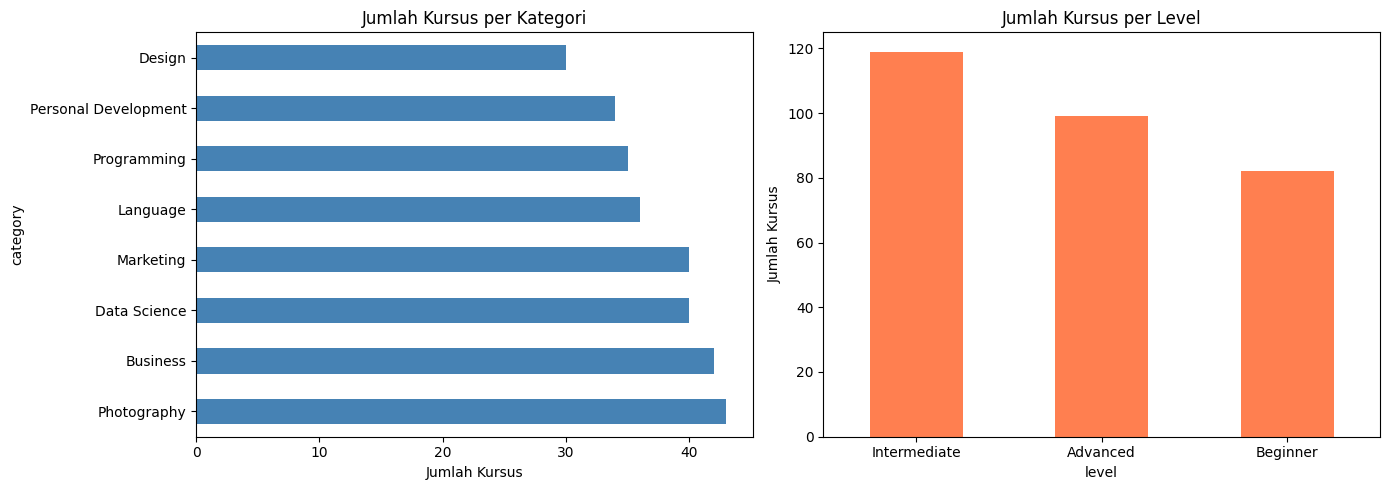

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dim_courses['category'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Jumlah Kursus per Kategori')
axes[0].set_xlabel('Jumlah Kursus')

dim_courses['level'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Jumlah Kursus per Level')
axes[1].set_ylabel('Jumlah Kursus')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## E2: Distribusi Jumlah Enrollment per Kategori Kursus

In [ ]:
# === E2: Distribusi enrollment per kategori kursus ===
enroll_category = fact_enrollments.merge(dim_courses[['course_id','category']], on='course_id')
enroll_per_category = enroll_category['category'].value_counts()

print("Jumlah enrollment per kategori:")
print(enroll_per_category)

# Enrollment per kursus (rata-rata) -- untuk lihat "demand" ternormalisasi per jumlah kursus
kursus_per_kategori = dim_courses['category'].value_counts()
avg_enroll_per_course = (enroll_per_category / kursus_per_kategori).sort_values(ascending=False)
print("\nRata-rata enrollment per kursus, per kategori:")
print(avg_enroll_per_course.round(1))

Jumlah enrollment per kategori:
category
Business                1157
Photography             1153
Data Science            1081
Marketing               1049
Language                 959
Programming              908
Personal Development     869
Design                   771
Name: count, dtype: int64

Rata-rata enrollment per kursus, per kategori:
category
Business                27.5
Data Science            27.0
Photography             26.8
Language                26.6
Marketing               26.2
Programming             25.9
Design                  25.7
Personal Development    25.6
Name: count, dtype: float64


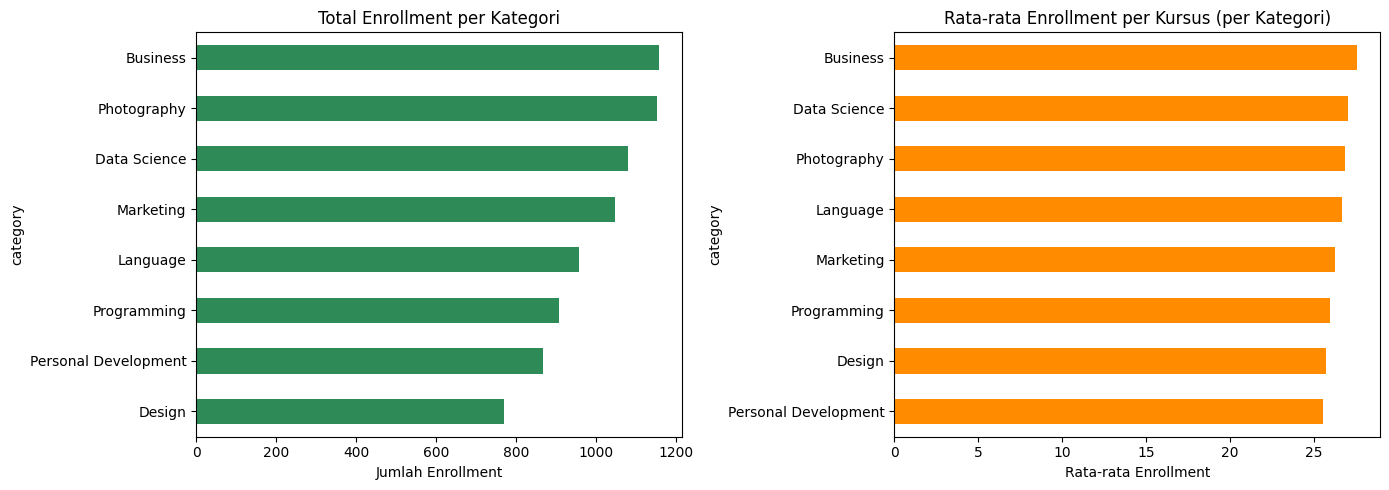

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

enroll_per_category.sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Total Enrollment per Kategori')
axes[0].set_xlabel('Jumlah Enrollment')

avg_enroll_per_course.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Rata-rata Enrollment per Kursus (per Kategori)')
axes[1].set_xlabel('Rata-rata Enrollment')

plt.tight_layout()
plt.show()

## E3: Tren Jumlah Enrollment per Bulan/Kuartal

In [ ]:
# === E3: Tren enrollment per bulan ===
fact_enrollments['enroll_month'] = fact_enrollments['enrollment_date'].dt.to_period('M')
tren_bulanan = fact_enrollments.groupby('enroll_month').size()

print("Tren enrollment per bulan:")
print(tren_bulanan)

Tren enrollment per bulan:
enroll_month
2023-08      2
2023-09      3
2023-10      6
2023-11      5
2023-12     12
2024-01     17
2024-02     18
2024-03     30
2024-04     23
2024-05     38
2024-06     43
2024-07     44
2024-08     58
2024-09     60
2024-10     61
2024-11     80
2024-12     92
2025-01    109
2025-02     93
2025-03    125
2025-04    153
2025-05    177
2025-06    181
2025-07    234
2025-08    252
2025-09    284
2025-10    298
2025-11    314
2025-12    363
2026-01    454
2026-02    498
2026-03    579
2026-04    610
2026-05    738
2026-06    902
2026-07    991
Freq: M, dtype: int64


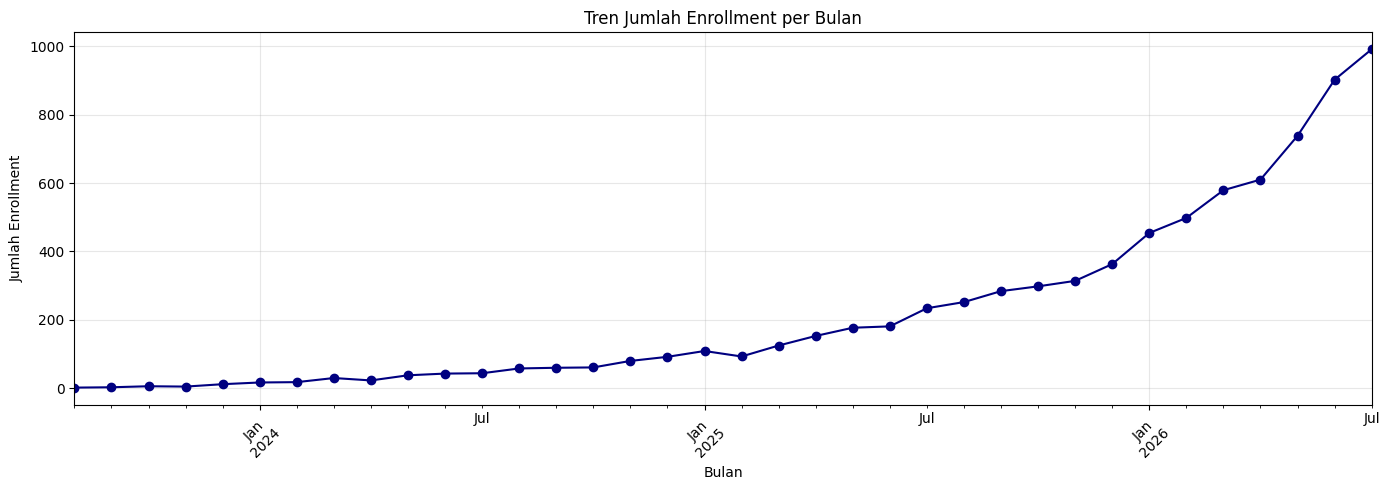

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
tren_bulanan.plot(kind='line', marker='o', ax=ax, color='navy')
ax.set_title('Tren Jumlah Enrollment per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Enrollment')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## E4: Distribusi enrollment_source

In [ ]:
# === E4: Distribusi enrollment_source dan proporsinya ===
source_dist = fact_enrollments['enrollment_source'].value_counts()
source_pct = fact_enrollments['enrollment_source'].value_counts(normalize=True).round(3) * 100

print("Distribusi enrollment_source:")
print(pd.DataFrame({'jumlah': source_dist, 'persen': source_pct}))

Distribusi enrollment_source:
                   jumlah  persen
enrollment_source                
promo                2069    26.0
organic              2045    25.7
ads                  1957    24.6
referral             1876    23.6


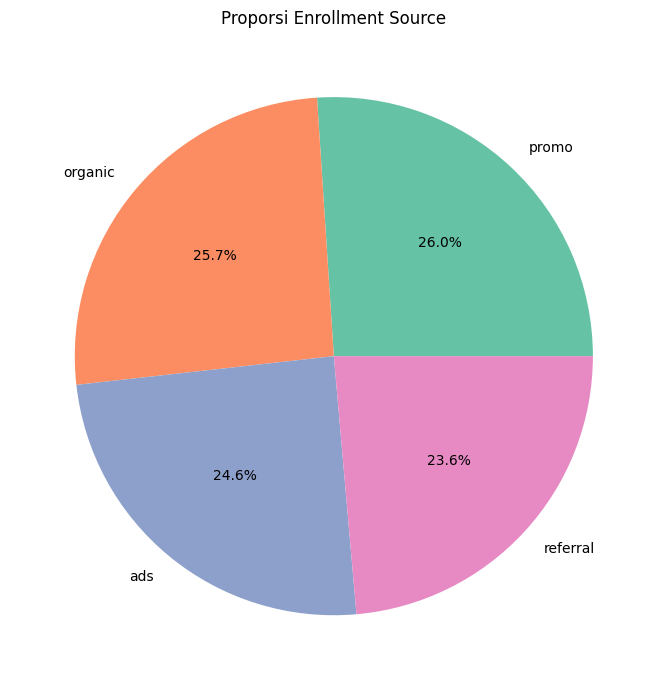

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
source_dist.plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=sns.color_palette('Set2'))
ax.set_title('Proporsi Enrollment Source')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## E5: Completion Rate Keseluruhan Platform (Baseline)

In [ ]:
# === E5: Completion rate keseluruhan platform ===

# Hitung jumlah modul completed per enrollment, dibandingkan total_modules course terkait
progress_summary = fact_progress.groupby('enrollment_id').agg(
    modul_completed=('status', lambda x: (x == 'completed').sum()),
    modul_diakses=('status', 'count')
).reset_index()

enrollment_full = fact_enrollments.merge(progress_summary, on='enrollment_id', how='left')
enrollment_full = enrollment_full.merge(dim_courses[['course_id','total_modules']], on='course_id')

# Enrollment tanpa baris progress sama sekali (ghost user) -> modul_completed & modul_diakses jadi NaN, isi 0
enrollment_full['modul_completed'] = enrollment_full['modul_completed'].fillna(0)
enrollment_full['modul_diakses'] = enrollment_full['modul_diakses'].fillna(0)

# Course dianggap SELESAI jika modul_completed == total_modules (semua modul selesai)
enrollment_full['is_completed'] = enrollment_full['modul_completed'] >= enrollment_full['total_modules']

completion_rate_keseluruhan = enrollment_full['is_completed'].mean() * 100
print(f"Completion rate keseluruhan platform: {completion_rate_keseluruhan:.2f}%")
print(f"Total enrollment: {len(enrollment_full)}")
print(f"Enrollment completed: {enrollment_full['is_completed'].sum()}")
print(f"Enrollment belum completed: {(~enrollment_full['is_completed']).sum()}")

# Breakdown ghost user vs yang punya progress tapi belum selesai
ghost = enrollment_full[enrollment_full['modul_diakses'] == 0]
print(f"\nDari yang belum completed, ghost user (0 progress): {len(ghost)} ({len(ghost)/len(enrollment_full)*100:.1f}% dari total)")

Completion rate keseluruhan platform: 28.74%
Total enrollment: 7947
Enrollment completed: 2284
Enrollment belum completed: 5663

Dari yang belum completed, ghost user (0 progress): 1175 (14.8% dari total)


### E5 (lanjutan): Completion Rate Adjusted (Exclude Enrollment yang Masih Sangat Baru)

In [ ]:
# === E5 (lanjutan): Completion rate untuk enrollment yang sudah "cukup waktu" (>= 3 bulan sejak enrollment_date) ===
tanggal_cutoff = pd.Timestamp('2026-08-05') - pd.DateOffset(months=3)  # enrollment sebelum 5 Mei 2026

enrollment_matang = enrollment_full[enrollment_full['enrollment_date'] <= tanggal_cutoff]
completion_rate_matang = enrollment_matang['is_completed'].mean() * 100

print(f"Cutoff: enrollment sebelum {tanggal_cutoff.date()}")
print(f"Jumlah enrollment yang sudah matang (>=3 bulan): {len(enrollment_matang)} dari {len(enrollment_full)} ({len(enrollment_matang)/len(enrollment_full)*100:.1f}%)")
print(f"Completion rate (enrollment matang saja): {completion_rate_matang:.2f}%")

print(f"\nPerbandingan:")
print(f"  - Completion rate keseluruhan (semua enrollment): {completion_rate_keseluruhan:.2f}%")
print(f"  - Completion rate enrollment matang (>=3 bulan): {completion_rate_matang:.2f}%")

Cutoff: enrollment sebelum 2026-05-05
Jumlah enrollment yang sudah matang (>=3 bulan): 5421 dari 7947 (68.2%)
Completion rate (enrollment matang saja): 27.87%

Perbandingan:
  - Completion rate keseluruhan (semua enrollment): 28.74%
  - Completion rate enrollment matang (>=3 bulan): 27.87%


## E6: Completion Rate per Kategori Kursus (Bar Chart, Urutkan dari Terendah)

In [ ]:
# === E6: Completion rate per kategori kursus ===
enrollment_full_cat = enrollment_full.merge(dim_courses[['course_id','category']], on='course_id')

completion_per_category = enrollment_full_cat.groupby('category')['is_completed'].agg(
    total_enrollment='count',
    completed='sum'
)
completion_per_category['completion_rate_%'] = (completion_per_category['completed'] / completion_per_category['total_enrollment'] * 100).round(2)
completion_per_category = completion_per_category.sort_values('completion_rate_%')

print(completion_per_category)

                      total_enrollment  completed  completion_rate_%
category                                                            
Programming                        908        242              26.65
Language                           959        256              26.69
Personal Development               869        240              27.62
Business                          1157        325              28.09
Data Science                      1081        306              28.31
Marketing                         1049        310              29.55
Design                             771        237              30.74
Photography                       1153        368              31.92


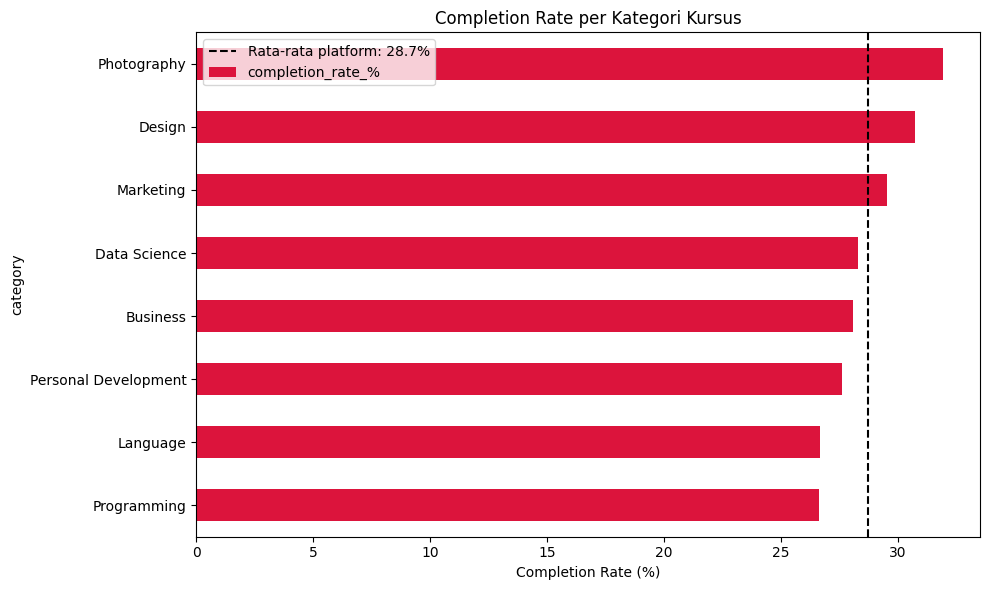

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
completion_per_category['completion_rate_%'].plot(kind='barh', ax=ax, color='crimson')
ax.axvline(completion_rate_keseluruhan, color='black', linestyle='--', label=f'Rata-rata platform: {completion_rate_keseluruhan:.1f}%')
ax.set_title('Completion Rate per Kategori Kursus')
ax.set_xlabel('Completion Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## E7: Completion Rate per Level Kursus

In [ ]:
# === E7: Completion rate per level kursus ===
enrollment_full_level = enrollment_full.merge(dim_courses[['course_id','level']], on='course_id')

completion_per_level = enrollment_full_level.groupby('level')['is_completed'].agg(
    total_enrollment='count',
    completed='sum'
)
completion_per_level['completion_rate_%'] = (completion_per_level['completed'] / completion_per_level['total_enrollment'] * 100).round(2)
completion_per_level = completion_per_level.reindex(['Beginner','Intermediate','Advanced'])

print(completion_per_level)

              total_enrollment  completed  completion_rate_%
level                                                       
Beginner                  2229        657              29.48
Intermediate              3045        899              29.52
Advanced                  2673        728              27.24


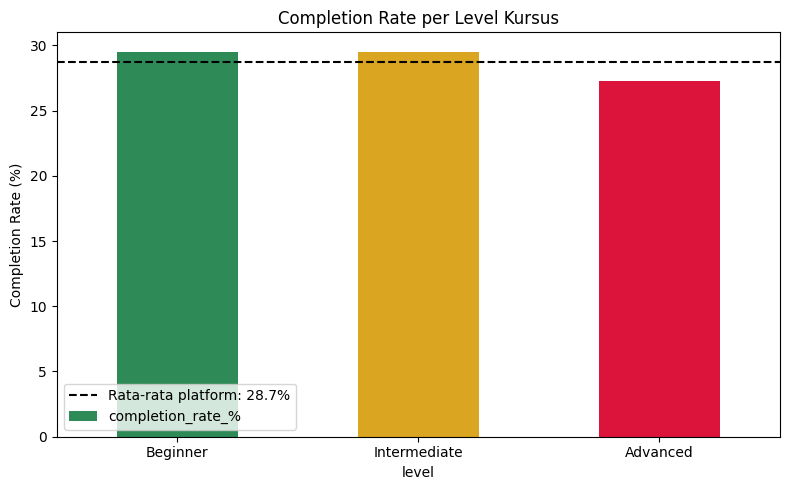

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
completion_per_level['completion_rate_%'].plot(kind='bar', ax=ax, color=['seagreen','goldenrod','crimson'])
ax.axhline(completion_rate_keseluruhan, color='black', linestyle='--', label=f'Rata-rata platform: {completion_rate_keseluruhan:.1f}%')
ax.set_title('Completion Rate per Level Kursus')
ax.set_ylabel('Completion Rate (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

## E8: Distribusi Rating Kursus & Rata-rata Rating per Kategori

In [ ]:
# === E8: Distribusi rating & rata-rata rating per kategori ===
print("Distribusi rating (histogram data):")
print(fact_reviews['rating'].value_counts().sort_index())
print(f"\nRata-rata rating keseluruhan: {fact_reviews['rating'].mean():.2f}")

# Rata-rata rating per kategori (join review -> enrollment -> course)
review_with_category = fact_reviews.merge(fact_enrollments[['enrollment_id','course_id']], on='enrollment_id')\
    .merge(dim_courses[['course_id','category']], on='course_id')

avg_rating_per_category = review_with_category.groupby('category')['rating'].agg(
    jumlah_review='count',
    rata_rata_rating='mean'
).round(2).sort_values('rata_rata_rating', ascending=False)

print("\nRata-rata rating per kategori:")
print(avg_rating_per_category)

Distribusi rating (histogram data):
rating
1      98
2     174
3     471
4    1217
5    1663
Name: count, dtype: int64

Rata-rata rating keseluruhan: 4.15

Rata-rata rating per kategori:
                      jumlah_review  rata_rata_rating
category                                             
Business                        504              4.21
Language                        462              4.20
Marketing                       491              4.18
Programming                     409              4.17
Data Science                    491              4.15
Design                          371              4.13
Personal Development            377              4.11
Photography                     518              4.06


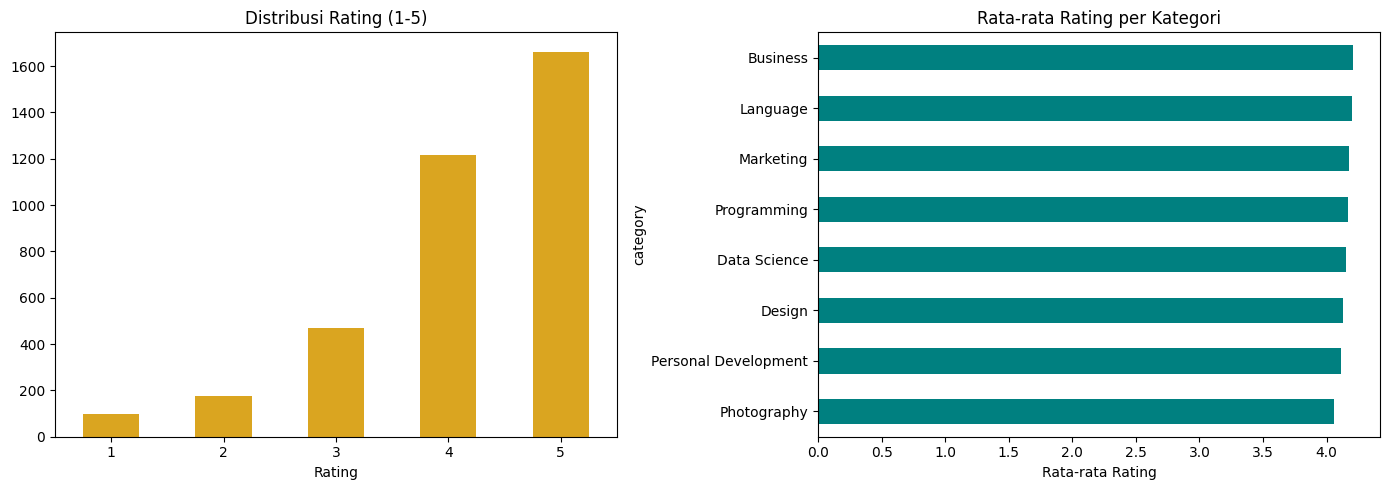

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fact_reviews['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Distribusi Rating (1-5)')
axes[0].set_xlabel('Rating')
axes[0].tick_params(axis='x', rotation=0)

avg_rating_per_category['rata_rata_rating'].sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Rata-rata Rating per Kategori')
axes[1].set_xlabel('Rata-rata Rating')

plt.tight_layout()
plt.show()

## E9: Distribusi Demografis User (Gender, Kota, Kelompok Usia)

In [ ]:
# === E9: Distribusi demografis user ===
print("Distribusi gender:")
print(dim_users['gender'].value_counts())

print("\nDistribusi kota (top 10):")
print(dim_users['city'].value_counts().head(10))

# Kelompok usia
dim_users['kelompok_usia'] = pd.cut(dim_users['usia'], bins=[0,20,30,40,50,100], labels=['<20','20-29','30-39','40-49','50+'])
print("\nDistribusi kelompok usia:")
print(dim_users['kelompok_usia'].value_counts().sort_index())

Distribusi gender:
gender
Female    1030
Male       970
Name: count, dtype: int64

Distribusi kota (top 10):
city
Palembang    194
Jakarta      191
Makassar     190
Surabaya     188
Pekanbaru    182
Medan        181
Malang       181
Bandung      179
Denpasar     179
Semarang     173
Name: count, dtype: int64

Distribusi kelompok usia:
kelompok_usia
<20      211
20-29    503
30-39    483
40-49    533
50+      270
Name: count, dtype: int64


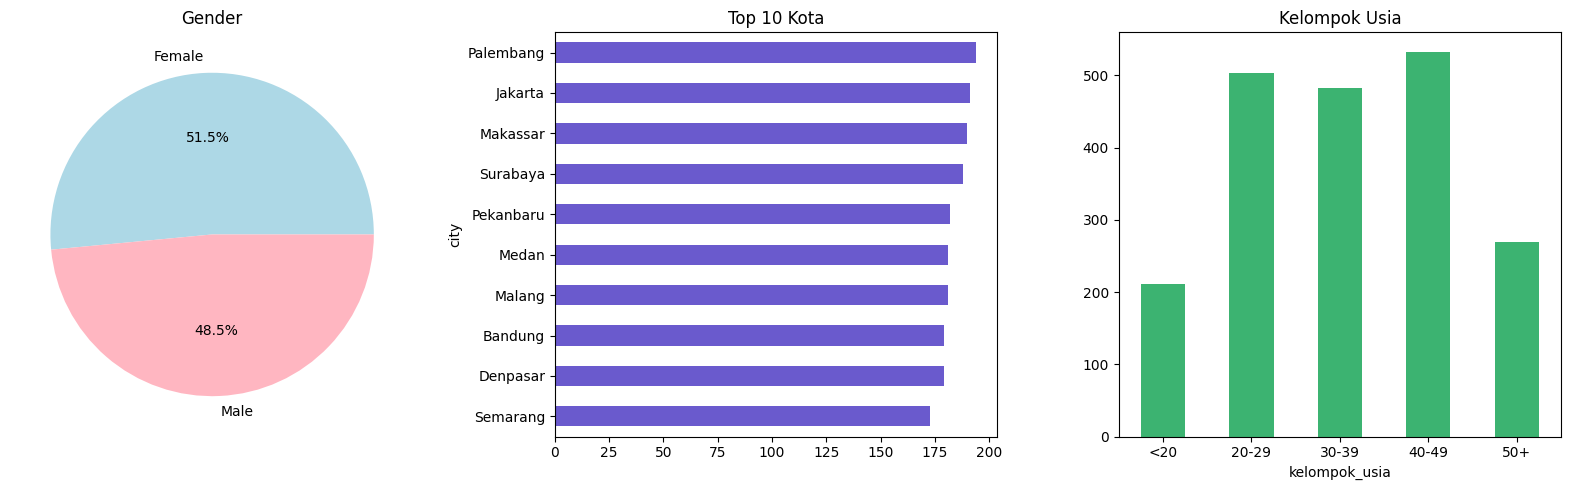

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dim_users['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['lightblue','lightpink'])
axes[0].set_title('Gender')
axes[0].set_ylabel('')

dim_users['city'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Top 10 Kota')
axes[1].invert_yaxis()

dim_users['kelompok_usia'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Kelompok Usia')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## E10: Distribusi time_spent_minutes (Boxplot, Verifikasi Hasil Outlier Handling)

In [ ]:
# === E10: Distribusi time_spent_minutes setelah cleaning -- verifikasi hasil D1-D3 ===
print("Statistik time_spent_minutes setelah cleaning:")
print(fact_progress['time_spent_minutes'].describe())

print("\nBreakdown berdasarkan flag:")
print(fact_progress.groupby('time_spent_flag')['time_spent_minutes'].describe())

Statistik time_spent_minutes setelah cleaning:
count    35167.000000
mean        39.792316
std         24.984896
min          1.000000
25%         23.000000
50%         37.000000
75%         52.000000
max        300.000000
Name: time_spent_minutes, dtype: float64

Breakdown berdasarkan flag:
                       count        mean        std   min    25%    50%  \
time_spent_flag                                                           
normal               34820.0   38.443395  19.769336   1.0   22.0   36.0   
was_extreme_outlier    347.0  175.150904  74.549371  50.0  110.0  173.5   
was_negative             0.0         NaN        NaN   NaN    NaN    NaN   

                       75%    max  
time_spent_flag                    
normal                52.0  121.0  
was_extreme_outlier  242.5  300.0  
was_negative           NaN    NaN  


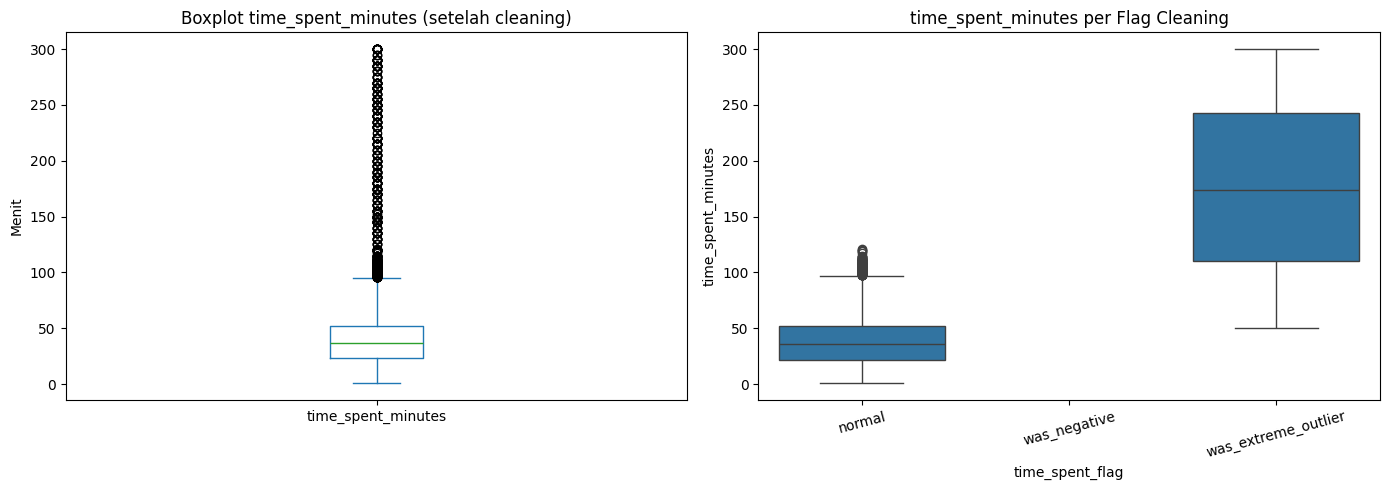

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fact_progress['time_spent_minutes'].dropna().plot(kind='box', ax=axes[0])
axes[0].set_title('Boxplot time_spent_minutes (setelah cleaning)')
axes[0].set_ylabel('Menit')

sns.boxplot(data=fact_progress, x='time_spent_flag', y='time_spent_minutes', ax=axes[1])
axes[1].set_title('time_spent_minutes per Flag Cleaning')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## E11: Proporsi account_status dan Hubungannya dengan Aktivitas Belajar Riil

In [ ]:
# === E11: account_status vs aktivitas belajar riil ===
print("Proporsi account_status:")
print(dim_users['account_status'].value_counts())
print(dim_users['account_status'].value_counts(normalize=True).round(3) * 100)

Proporsi account_status:
account_status
active      1617
inactive     383
Name: count, dtype: int64
account_status
active      80.8
inactive    19.2
Name: proportion, dtype: float64


In [ ]:
# Cek aktivitas riil: apakah user "inactive" benar-benar tidak aktif belajar?
user_progress = fact_enrollments.merge(fact_progress.groupby('enrollment_id').size().rename('jumlah_progress'),
                                         on='enrollment_id', how='left')
user_progress['jumlah_progress'] = user_progress['jumlah_progress'].fillna(0)

user_activity = user_progress.groupby('user_id')['jumlah_progress'].sum().reset_index()
user_activity = user_activity.merge(dim_users[['user_id','account_status']], on='user_id')

print("\nRata-rata jumlah progress (aktivitas belajar) per account_status:")
print(user_activity.groupby('account_status')['jumlah_progress'].describe())

# Cek user inactive yang MASIH punya aktivitas belajar signifikan (>0)
inactive_tapi_aktif = user_activity[(user_activity['account_status'] == 'inactive') & (user_activity['jumlah_progress'] > 0)]
print(f"\nUser 'inactive' tapi punya histori progress: {len(inactive_tapi_aktif)} dari {(user_activity['account_status']=='inactive').sum()} user inactive")


Rata-rata jumlah progress (aktivitas belajar) per account_status:
                 count       mean        std  min   25%   50%   75%   max
account_status                                                           
active          1592.0  18.098618  11.062519  0.0  10.0  17.0  25.0  62.0
inactive         375.0  17.901333  11.629226  0.0   9.5  16.0  24.0  64.0

User 'inactive' tapi punya histori progress: 373 dari 375 user inactive


## E12: Jumlah User per "Learner Profile" Implisit

In [ ]:
# === E12: Kelompokkan user berdasarkan pola perilaku belajar (learner profile implisit) ===

# Gabungkan info completion & progress per enrollment
enrollment_profile = enrollment_full.copy()
enrollment_profile['pct_completed'] = (enrollment_profile['modul_completed'] / enrollment_profile['total_modules'] * 100).round(1)

def klasifikasi_profile(row):
    if row['modul_diakses'] == 0:
        return 'ghost_user'
    elif row['pct_completed'] >= 100:
        return 'completer'
    elif row['pct_completed'] <= 25:
        return 'early_dropper'
    elif row['pct_completed'] <= 75:
        return 'mid_dropper'
    else:
        return 'slow_learner_or_near_complete'

enrollment_profile['learner_profile'] = enrollment_profile.apply(klasifikasi_profile, axis=1)

print("Distribusi learner profile (hasil rekonstruksi):")
print(enrollment_profile['learner_profile'].value_counts())
print(enrollment_profile['learner_profile'].value_counts(normalize=True).round(3) * 100)

Distribusi learner profile (hasil rekonstruksi):
learner_profile
mid_dropper                      2364
completer                        2284
early_dropper                    1817
ghost_user                       1175
slow_learner_or_near_complete     307
Name: count, dtype: int64
learner_profile
mid_dropper                      29.7
completer                        28.7
early_dropper                    22.9
ghost_user                       14.8
slow_learner_or_near_complete     3.9
Name: proportion, dtype: float64


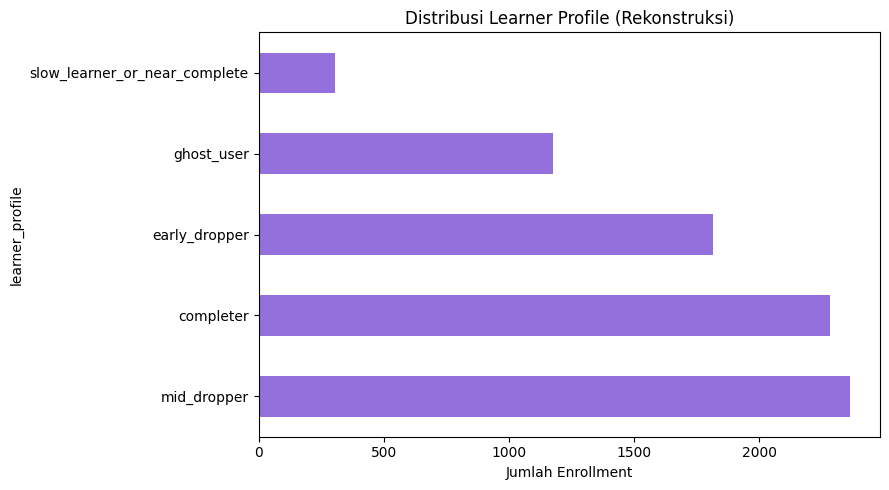

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
enrollment_profile['learner_profile'].value_counts().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Distribusi Learner Profile (Rekonstruksi)')
ax.set_xlabel('Jumlah Enrollment')
plt.tight_layout()
plt.show()

## Dokumentasi Resmi Bagian E (penutup)

In [ ]:
dokumentasi_E = """
=== RINGKASAN BAGIAN E — EXPLORATORY DATA ANALYSIS (EDA) ===

E1. Distribusi kursus: 8 kategori cukup merata (30-43 kursus). Level condong ke
    Intermediate (119) > Advanced (99) > Beginner (82). Kategori Business punya proporsi
    Advanced tinggi tapi Beginner rendah (23 vs 5) -- pola tidak biasa, dicatat sebagai observasi.

E2. Distribusi enrollment: total enrollment tertinggi di Business (1157) & Photography (1153),
    tapi setelah dinormalisasi per jumlah kursus, gap antar kategori jadi kecil (25.6-27.5
    rata-rata per kursus) -- demand sebenarnya cukup merata.

E3. Tren enrollment per bulan: pertumbuhan EKSPONENSIAL (2 -> 991 per bulan, Agustus 2023
    s/d Juli 2026), akselerasi tajam sejak awal 2026. ~25% total enrollment terjadi
    dalam 2 bulan terakhir saja.

E4. Enrollment source: sangat merata (organic 25.7%, promo 26.0%, ads 24.6%,
    referral 23.6%) -- tidak ada sumber akuisisi yang dominan.

E5. Completion rate keseluruhan platform: 28.74% (2284 dari 7947 enrollment).
    Completion rate untuk enrollment matang (>=3 bulan): 27.87% -- HAMPIR SAMA dengan
    keseluruhan, membuktikan completion rate rendah BUKAN artefak dari growth pesat platform,
    melainkan pola yang konsisten. 14.8% enrollment adalah ghost user (0 progress).

E6. Completion rate per kategori: rentang 26.65% (Programming, terendah) - 31.92%
    (Photography, tertinggi). Gap antar kategori relatif sempit (~5 poin) -- masalah
    completion rate rendah bersifat PLATFORM-WIDE, bukan spesifik ke kategori tertentu.

E7. Completion rate per level: Advanced terendah (27.24%), Beginner & Intermediate
    hampir sama (29.48% vs 29.52%). Pola wajar secara pedagogis.

E8. Rating: rata-rata keseluruhan 4.15, sangat merata antar kategori (4.06-4.21).
    TEMUAN PENTING: pola berlawanan dengan completion rate -- Photography rating
    TERENDAH (4.06) tapi completion rate TERTINGGI (31.92%); Programming rating
    di atas rata-rata (4.17) tapi completion rate TERENDAH (26.65%). Indikasi awal
    rating TIDAK berkorelasi kuat (bahkan mungkin berlawanan arah) dengan completion rate --
    akan diuji formal di analisis korelasi.

E9. Demografi: gender seimbang (51.5% Female/48.5% Male), kota tersebar merata
    (tidak ada dominasi kota tertentu), usia mayoritas 20-49 tahun. Tidak ada pola
    signifikan untuk ditindaklanjuti.

E10. Verifikasi time_spent_minutes pasca-cleaning: distribusi rapi, tidak ada nilai
     negatif tersisa, outlier ekstrem (347 baris) sudah ter-cap proporsional per modul.

E11. TEMUAN PENTING: account_status TIDAK mencerminkan aktivitas belajar riil.
     Rata-rata progress user 'inactive' (17.9) HAMPIR SAMA dengan user 'active' (18.1).
     99.5% user inactive tetap punya histori progress substansial. Rekomendasi: klien
     TIDAK sebaiknya memakai account_status sebagai proxy engagement/keaktifan belajar.

E12. Rekonstruksi learner profile: mid_dropper (29.7%, kelompok terbesar -- prioritas
     utama strategi engagement), completer (28.7%, konsisten dgn E5), early_dropper
     (22.9%, kandidat investigasi modul awal/onboarding), ghost_user (14.8%, sesuai
     dokumentasi), slow_learner_or_near_complete (3.9%, kandidat quick-win reminder).
"""
output_path = '/content/drive/MyDrive/Data Analyst/EduSmart'
with open(f'{output_path}/data_cleaning_log.txt', 'a') as f:
    f.write(dokumentasi_E)
print("Dokumentasi Bagian E ditambahkan ke data_cleaning_log.txt")

Dokumentasi Bagian E ditambahkan ke data_cleaning_log.txt
